In [ ]:
# ══════════════════════════════════════════════════════════════════
# # Builds 3-channel jet image dataset (125 GeV)
# 
# Arrays saved:
#   images    (N, 3, 32, 32)  float32
#   labels    (N,)             int8     1=tau, 0=background
#   sample_id (N,)             int8     0=tau, 1=jj, 2=bb
#   jet_pt    (N,)             float32
#   event_id  (N,)             int32
# ══════════════════════════════════════════════════════════════════

from pathlib import Path
import uproot
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from tqdm import tqdm

# ── paths ─────────────────────────────────────────────────────────
ROOT_PATH = Path("E:/Python/MSc_Project_Upgrade/generation/root_files")
SAVE_PATH = Path("E:/Python/MSc_Project_Upgrade/datasets/cnn_vit")
SAVE_PATH.mkdir(parents=True, exist_ok=True)

VIZ_PATH  = Path("E:/Python/MSc_Project_Upgrade/results_analysis/jet_images/")
VIZ_PATH.mkdir(parents=True, exist_ok=True)

# ── config ────────────────────────────────────────────────────────
IMAGE_SIZE = 32
ETA_RANGE  = 1.0
PHI_RANGE  = 1.0
PT_MIN     = 15.0
PT_MAX     = 150.0
DR_CONE    = 0.4


In [ ]:
def build_jet_image(jet_eta, jet_phi,
                    trk_eta, trk_phi, trk_pt,
                    pho_eta, pho_phi, pho_et,
                    neu_eta, neu_phi, neu_et):
    """
    Builds a 3-channel (32x32) jet image in eta-phi plane.
    Channels : [EFlowTrack, EFlowPhoton, EFlowNeutralHadron]
    Pipeline  : centering -> PCA rotation -> energy flip (post-rot) -> L2 norm
    """

    img = np.zeros((3, IMAGE_SIZE, IMAGE_SIZE), dtype=np.float32)

    # ── CENTERING ────────────────────────────────────────────────
    def center(eta, phi):
        deta = eta - jet_eta
        dphi = (phi - jet_phi + np.pi) % (2 * np.pi) - np.pi
        return deta, dphi

    trk_deta, trk_dphi = center(trk_eta, trk_phi)
    pho_deta, pho_dphi = center(pho_eta, pho_phi)
    neu_deta, neu_dphi = center(neu_eta, neu_phi)

    # ── PCA ROTATION ─────────────────────────────────────────────
    all_deta = np.concatenate([trk_deta, pho_deta, neu_deta])
    all_dphi = np.concatenate([trk_dphi, pho_dphi, neu_dphi])
    all_pt   = np.concatenate([trk_pt,   pho_et,   neu_et])

    if all_pt.sum() > 0:
        coords            = np.vstack([all_deta, all_dphi]).T
        cov               = np.cov(coords.T, aweights=all_pt)
        eigvals, eigvecs  = np.linalg.eigh(cov)
        principal         = eigvecs[:, -1]          # largest eigenvector
        angle             = np.arctan2(principal[1], principal[0])

        def rotate(deta, dphi):
            cos_a = np.cos(-angle)
            sin_a = np.sin(-angle)
            return cos_a * deta - sin_a * dphi, sin_a * deta + cos_a * dphi

        trk_deta, trk_dphi = rotate(trk_deta, trk_dphi)
        pho_deta, pho_dphi = rotate(pho_deta, pho_dphi)
        neu_deta, neu_dphi = rotate(neu_deta, neu_dphi)

        # ── ENERGY FLIP — uses POST-rotation deta ─────────────
        all_deta_rot = np.concatenate([trk_deta, pho_deta, neu_deta])
        left  = all_pt[all_deta_rot < 0].sum()
        right = all_pt[all_deta_rot >= 0].sum()

        if left > right:
            trk_deta *= -1
            pho_deta *= -1
            neu_deta *= -1

    # ── HISTOGRAM BINNING ────────────────────────────────────────
    def fill_hist(deta, dphi, pt):
        H, _, _ = np.histogram2d(
            deta, dphi,
            bins    = IMAGE_SIZE,
            range   = [[-ETA_RANGE, ETA_RANGE], [-PHI_RANGE, PHI_RANGE]],
            weights = pt
        )
        return H.astype(np.float32)

    img[0] = fill_hist(trk_deta, trk_dphi, trk_pt)
    img[1] = fill_hist(pho_deta, pho_dphi, pho_et)
    img[2] = fill_hist(neu_deta, neu_dphi, neu_et)

    # ── L2 NORMALIZATION ─────────────────────────────────────────
    norm = np.sqrt((img ** 2).sum())
    if norm > 0:
        img /= norm

    return img

In [ ]:
def extract_images(root_file, label, sample_name, event_offset):
    """
    Extracts all valid jet images from a ROOT file.
    Valid = passes pT window + non-zero constituents within dR < 0.4.

    Returns
    -------
    images     : (N, 3, 32, 32) float32
    labels     : (N,)           int8
    jet_pts    : (N,)           float32
    event_ids  : (N,)           int32
    n_events   : int   — total events in tree (used for event_offset)
    """
    print(f"\n{'='*60}")
    print(f"  Processing : {sample_name}")
    print(f"{'='*60}")

    tree = uproot.open(root_file)["Delphes;1"]

    jet_pt  = tree["Jet/Jet.PT"].array(library="ak")
    jet_eta = tree["Jet/Jet.Eta"].array(library="ak")
    jet_phi = tree["Jet/Jet.Phi"].array(library="ak")

    trk_eta = tree["EFlowTrack/EFlowTrack.Eta"].array(library="ak")
    trk_phi = tree["EFlowTrack/EFlowTrack.Phi"].array(library="ak")
    trk_pt  = tree["EFlowTrack/EFlowTrack.PT"].array(library="ak")

    pho_eta = tree["EFlowPhoton/EFlowPhoton.Eta"].array(library="ak")
    pho_phi = tree["EFlowPhoton/EFlowPhoton.Phi"].array(library="ak")
    pho_et  = tree["EFlowPhoton/EFlowPhoton.ET"].array(library="ak")

    neu_eta = tree["EFlowNeutralHadron/EFlowNeutralHadron.Eta"].array(library="ak")
    neu_phi = tree["EFlowNeutralHadron/EFlowNeutralHadron.Phi"].array(library="ak")
    neu_et  = tree["EFlowNeutralHadron/EFlowNeutralHadron.ET"].array(library="ak")

    images, labels, jet_pts, event_ids = [], [], [], []
    n_events      = len(jet_pt)
    skipped_pt    = 0
    skipped_empty = 0

    for ev in tqdm(range(n_events), desc=f"  {sample_name}"):

        for j in range(len(jet_pt[ev])):

            jpt = float(jet_pt[ev][j])
            if jpt < PT_MIN or jpt > PT_MAX:
                skipped_pt += 1
                continue

            j_eta = float(jet_eta[ev][j])
            j_phi = float(jet_phi[ev][j])

            def cone(p_eta, p_phi, p_pt):
                p_eta = np.asarray(p_eta, dtype=np.float32)
                p_phi = np.asarray(p_phi, dtype=np.float32)
                p_pt  = np.asarray(p_pt,  dtype=np.float32)
                deta  = p_eta - j_eta
                dphi  = (p_phi - j_phi + np.pi) % (2 * np.pi) - np.pi
                dR    = np.sqrt(deta ** 2 + dphi ** 2)
                mask  = dR < DR_CONE
                return p_eta[mask], p_phi[mask], p_pt[mask]

            t_eta, t_phi, t_pt = cone(trk_eta[ev], trk_phi[ev], trk_pt[ev])
            p_eta, p_phi, p_et = cone(pho_eta[ev], pho_phi[ev], pho_et[ev])
            n_eta, n_phi, n_et = cone(neu_eta[ev], neu_phi[ev], neu_et[ev])

            if t_pt.sum() + p_et.sum() + n_et.sum() == 0:
                skipped_empty += 1
                continue

            img = build_jet_image(
                j_eta, j_phi,
                t_eta, t_phi, t_pt,
                p_eta, p_phi, p_et,
                n_eta, n_phi, n_et
            )

            images.append(img)
            labels.append(label)
            jet_pts.append(jpt)
            event_ids.append(ev + event_offset)

    print(f"\n  ── {sample_name} summary ──────────────────────")
    print(f"    Events processed  : {n_events}")
    print(f"    Jets built        : {len(images)}")
    print(f"    Skipped (pT cut)  : {skipped_pt}")
    print(f"    Skipped (empty)   : {skipped_empty}")

    return (np.array(images,    dtype=np.float32),
            np.array(labels,    dtype=np.int8),
            np.array(jet_pts,   dtype=np.float32),
            np.array(event_ids, dtype=np.int32),
            n_events)

In [ ]:
event_offset = 0

imgs_tau, lbl_tau, pt_tau, ev_tau, n_tau = extract_images(
    ROOT_PATH / "ee_tau_300GeV_50k_test.root", 1, "tau", event_offset)
event_offset += n_tau

imgs_jj, lbl_jj, pt_jj, ev_jj, n_jj = extract_images(
    ROOT_PATH / "ee_jj_300GeV_50k_test.root",  0, "jj",  event_offset)
event_offset += n_jj

imgs_bb, lbl_bb, pt_bb, ev_bb, n_bb = extract_images(
    ROOT_PATH / "ee_bb_300GeV_50k_test.root",  0, "bb",  event_offset)



images    = np.concatenate([imgs_tau, imgs_jj,  imgs_bb])
labels    = np.concatenate([lbl_tau,  lbl_jj,   lbl_bb])
jet_pt    = np.concatenate([pt_tau,   pt_jj,    pt_bb])
event_id  = np.concatenate([ev_tau,   ev_jj,    ev_bb])

# sample_id: 0=tau, 1=jj, 2=bb
sample_id = np.concatenate([
    np.zeros(len(lbl_tau), dtype=np.int8),
    np.ones (len(lbl_jj),  dtype=np.int8),
    np.full (len(lbl_bb),  2, dtype=np.int8)
])

n_sig = int((labels == 1).sum())
n_bkg = int((labels == 0).sum())

print(f"\n{'='*60}")
print(f"  MERGED DATASET (before shuffle)")
print(f"{'='*60}")
print(f"  Total jets      : {len(labels)}")
print(f"  Signal  (tau)   : {n_sig}   [sample_id=0]")
print(f"  Bkg     (jj)    : {int((sample_id==1).sum())}   [sample_id=1]")
print(f"  Bkg     (bb)    : {int((sample_id==2).sum())}   [sample_id=2]")
print(f"  Total bkg       : {n_bkg}")
print(f"  Ratio sig:bkg   : 1 : {n_bkg/n_sig:.2f}")
print(f"  Array size      : {images.nbytes / 1e9:.2f} GB")

# ── shuffle with fixed seed ───────────────────────────────────────
rng = np.random.default_rng(42)
idx = rng.permutation(len(labels))

images    = images[idx]
labels    = labels[idx]
jet_pt    = jet_pt[idx]
event_id  = event_id[idx]
sample_id = sample_id[idx]


  Processing : tau


  tau:   0%|          | 0/50000 [00:00<?, ?it/s]C:\Users\User\AppData\Local\Temp\ipykernel_21952\67214455.py:34: RuntimeWarning: Degrees of freedom <= 0 for slice
  cov               = np.cov(coords.T, aweights=all_pt)
  tau: 100%|██████████| 50000/50000 [04:31<00:00, 183.93it/s]



  ── tau summary ──────────────────────
    Events processed  : 50000
    Jets built        : 61871
    Skipped (pT cut)  : 156
    Skipped (empty)   : 0

  Processing : jj


  jj: 100%|██████████| 50000/50000 [10:42<00:00, 77.76it/s] 



  ── jj summary ──────────────────────
    Events processed  : 50000
    Jets built        : 120093
    Skipped (pT cut)  : 1006
    Skipped (empty)   : 0

  Processing : bb


  bb: 100%|██████████| 50000/50000 [18:22<00:00, 45.34it/s]  



  ── bb summary ──────────────────────
    Events processed  : 50000
    Jets built        : 120502
    Skipped (pT cut)  : 707
    Skipped (empty)   : 0

  MERGED DATASET (before shuffle)
  Total jets      : 302466
  Signal  (tau)   : 61871   [sample_id=0]
  Bkg     (jj)    : 120093   [sample_id=1]
  Bkg     (bb)    : 120502   [sample_id=2]
  Total bkg       : 240595
  Ratio sig:bkg   : 1 : 3.89
  Array size      : 3.72 GB


In [ ]:
out_file = SAVE_PATH / "jet_images_300GeV_test.npz"

np.savez_compressed(
    out_file,
    images    = images,
    labels    = labels,
    sample_id = sample_id,
    jet_pt    = jet_pt,
    event_id  = event_id
)

print(f"\n  Saved -> {out_file}")
print(f"  images    : {images.shape}   dtype={images.dtype}")
print(f"  labels    : {labels.shape}    dtype={labels.dtype}")
print(f"  sample_id : {sample_id.shape}    dtype={sample_id.dtype}")
print(f"  jet_pt    : {jet_pt.shape}    dtype={jet_pt.dtype}")
print(f"  event_id  : {event_id.shape}   dtype={event_id.dtype}")


  Saved -> E:\Python\MSc_Project_Upgrade\datasets\cnn_vit\jet_images_300GeV_test.npz
  images    : (302466, 3, 32, 32)   dtype=float32
  labels    : (302466,)    dtype=int8
  sample_id : (302466,)    dtype=int8
  jet_pt    : (302466,)    dtype=float32
  event_id  : (302466,)   dtype=int32


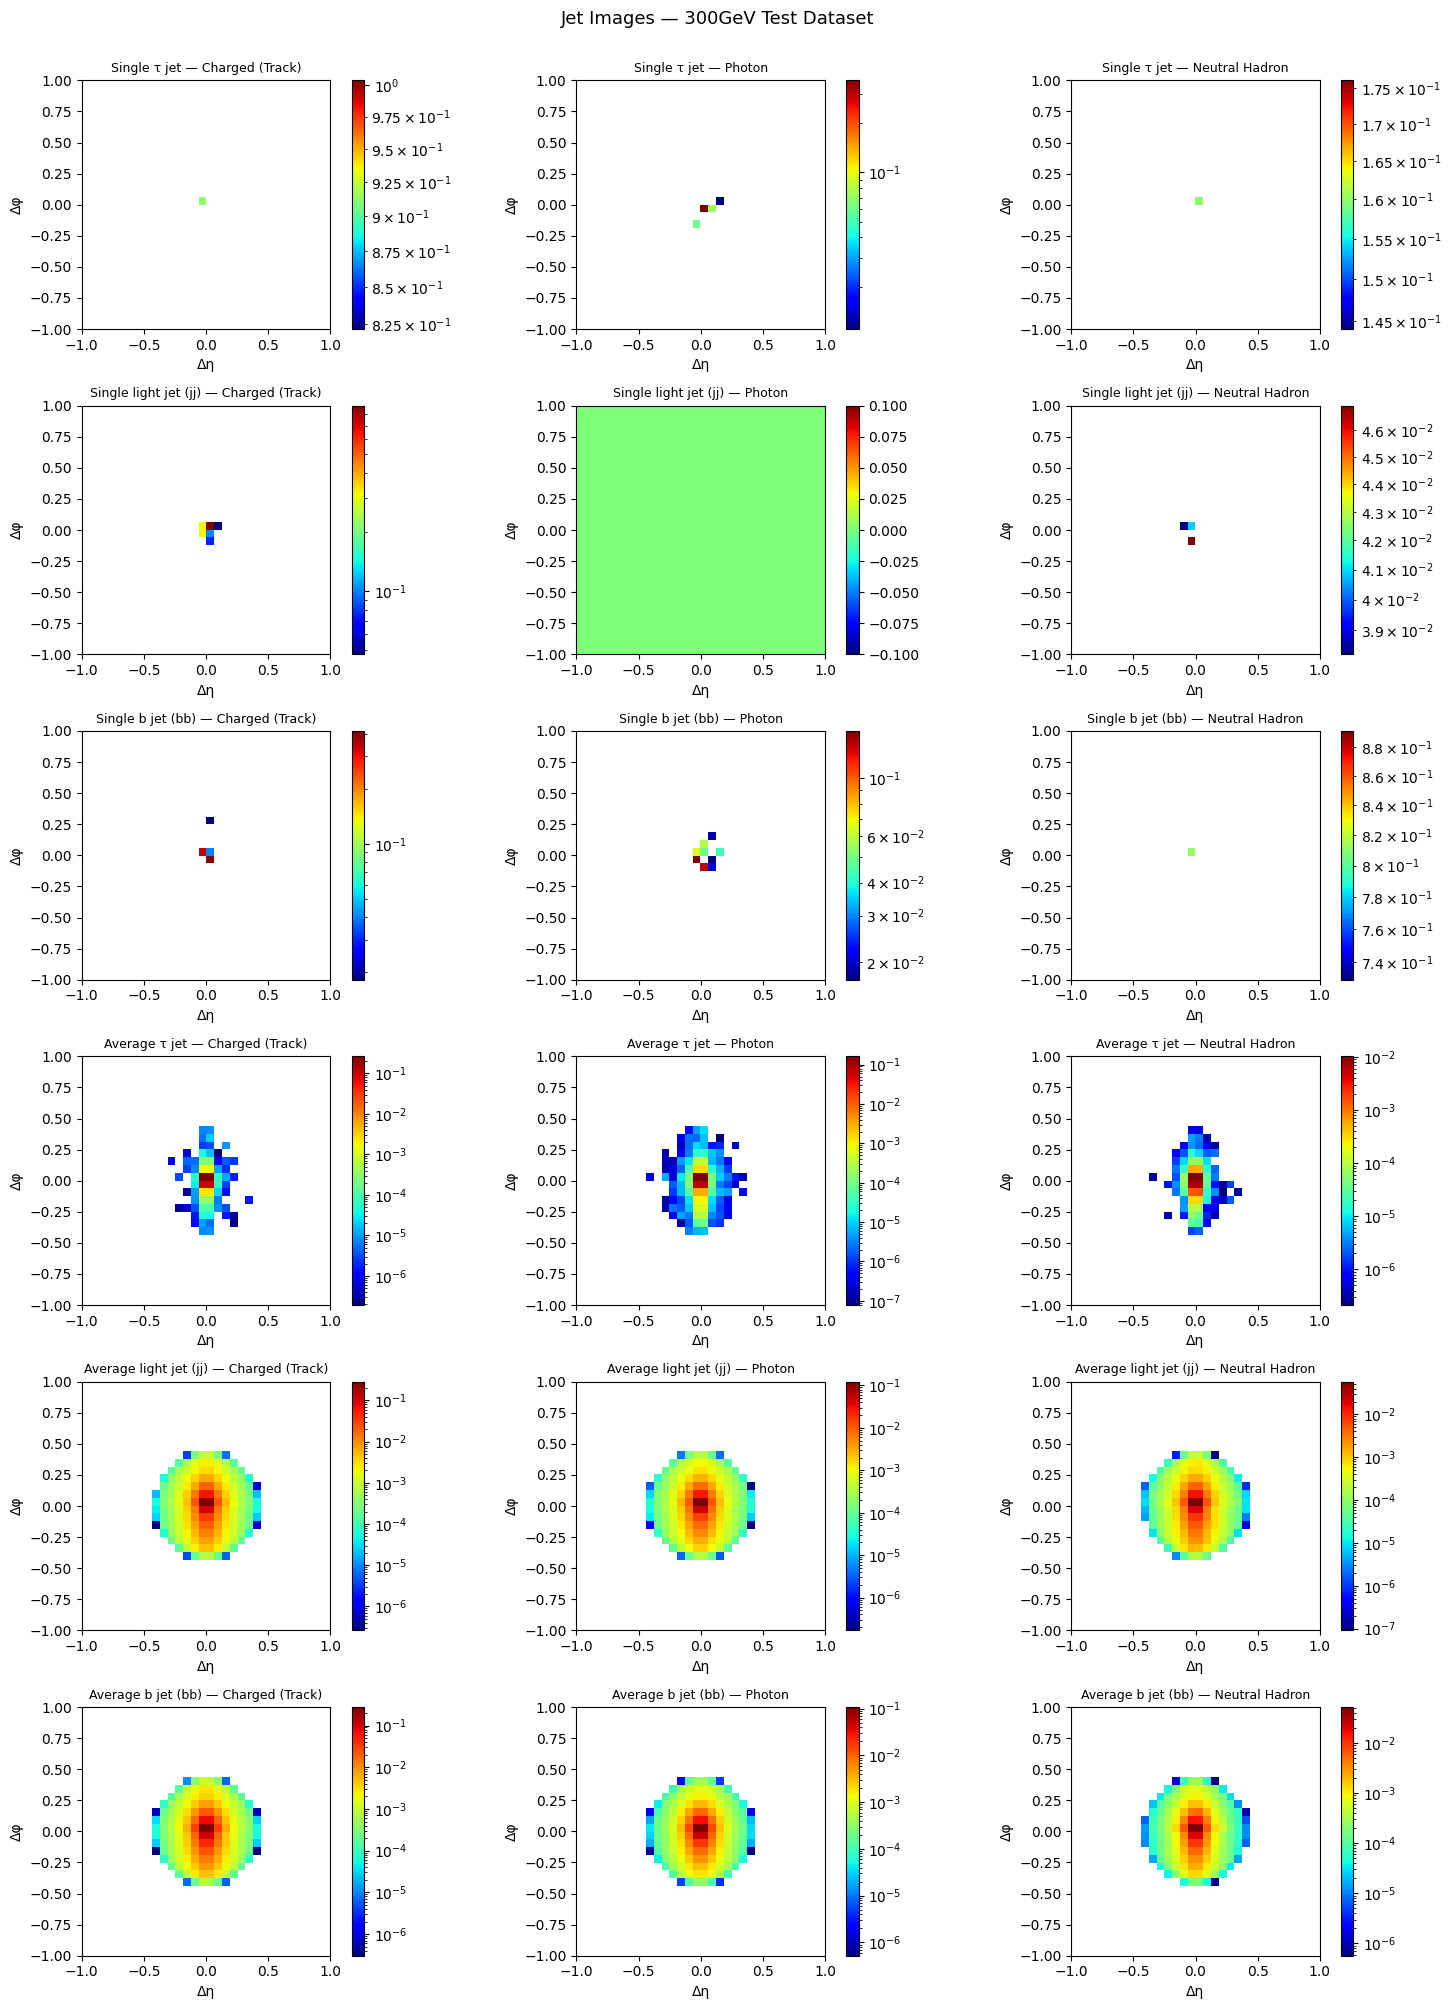

Visualization saved.


In [18]:
# ══════════════════════════════════════════════════════════════════
# SECTION 6 — Visualization  (6 rows x 3 channels)
#
#  Row 0 — single tau jet
#  Row 1 — single light jet (jj)
#  Row 2 — single b jet (bb)
#  Row 3 — average tau jet
#  Row 4 — average light jet (jj)
#  Row 5 — average b jet (bb)
# ══════════════════════════════════════════════════════════════════

channel_names = ["Charged (Track)", "Photon", "Neutral Hadron"]

def plot_row(ax_row, img_3ch, title_prefix):
    """
    Plots 3 channels of one jet image side by side.
    No manual re-normalisation — L2 norm already applied at build time.
    LogNorm vmin = smallest nonzero pixel to avoid log(0).
    """
    for col in range(3):
        ch = img_3ch[col]

        if ch.max() > 0:
            norm = LogNorm(vmin=ch[ch > 0].min(), vmax=ch.max())
        else:
            norm = None     # all-zero channel — imshow shows blank

        im = ax_row[col].imshow(
            ch,
            origin = "lower",
            cmap   = "jet",
            extent = [-1, 1, -1, 1],
            norm   = norm
        )
        ax_row[col].set_title(f"{title_prefix} — {channel_names[col]}", fontsize=9)
        ax_row[col].set_xlabel("Δη")
        ax_row[col].set_ylabel("Δφ")
        plt.colorbar(im, ax=ax_row[col])


# ── per-sample masks (use sample_id, NOT labels) ──────────────────
tau_mask = sample_id == 0
jj_mask  = sample_id == 1
bb_mask  = sample_id == 2

# ── singles ───────────────────────────────────────────────────────
tau_single = images[tau_mask][0]
jj_single  = images[jj_mask][0]
bb_single  = images[bb_mask][0]

# ── averages ──────────────────────────────────────────────────────
tau_avg = images[tau_mask].mean(axis=0)
jj_avg  = images[jj_mask].mean(axis=0)
bb_avg  = images[bb_mask].mean(axis=0)

# ── figure ────────────────────────────────────────────────────────
fig, axes = plt.subplots(6, 3, figsize=(15, 20))
plt.suptitle("Jet Images — 300GeV Test Dataset", fontsize=13, y=1.002)

plot_row(axes[0], tau_single, "Single τ jet")
plot_row(axes[1], jj_single,  "Single light jet (jj)")
plot_row(axes[2], bb_single,  "Single b jet (bb)")
plot_row(axes[3], tau_avg,    "Average τ jet")
plot_row(axes[4], jj_avg,     "Average light jet (jj)")
plot_row(axes[5], bb_avg,     "Average b jet (bb)")

plt.tight_layout()
plt.savefig(VIZ_PATH / "jet_images_300GeV_test.png", dpi=300, bbox_inches="tight")
plt.show()
print("Visualization saved.")